# Lineare Regression 1

y = a * x + b

In [99]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./data/Diamonds/diamonds.csv.bz2")

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


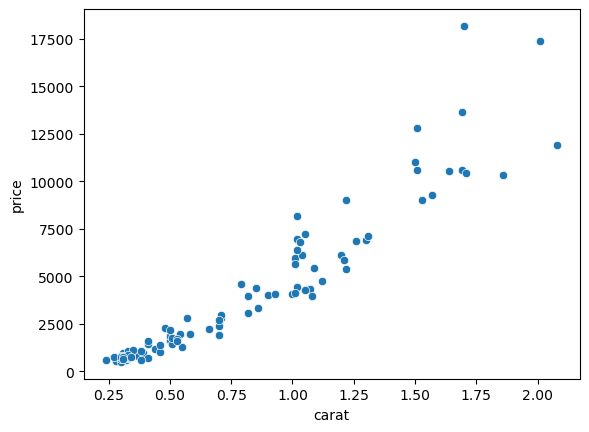

In [100]:
sns.scatterplot(data=df.sample(100), x="carat", y="price")
plt.show()


In [101]:
xs = df["carat"].to_numpy().reshape(-1, 1) # -1 = so viele Zeilen wie nötig, 1 = eine Spalte
print(xs.shape)

(53940, 1)


In [102]:
ys = df["price"].to_numpy()
print(ys.shape)

(53940,)


In [103]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit?


Signature: model.fit(X, y, sample_weight=None)
Docstring:
Fit linear model.

Parameters
----------
X : {array-like, sparse matrix} of shape (n_samples, n_features)
    Training data.

y : array-like of shape (n_samples,) or (n_samples, n_targets)
    Target values. Will be cast to X's dtype if necessary.

sample_weight : array-like of shape (n_samples,), default=None
    Individual weights for each sample.

    .. versionadded:: 0.17
       parameter *sample_weight* support to LinearRegression.

Returns
-------
self : object
    Fitted Estimator.
File:      ~/miniconda3/envs/jupyter-notebooks/lib/python3.13/site-packages/sklearn/linear_model/_base.py
Type:      method

In [104]:
model.fit(xs, ys)   # trainiert das Modell, lernt a und b aus der o.g. Gleichung

print(model.coef_)  # gibt a aus
print(model.intercept_)  # gibt b aus

[7756.42561797]
-2256.36058004672


Preis = 7756.42561797 * {Gewicht in Karat} + -2256.36058004672

In [105]:
def get_price(carat):
    return 7756.42561797 * carat - 2256.36058004672

In [106]:
print(get_price(0.5))
print(get_price(1.0))
print(get_price(1.5))
print(get_price(10.0))

1621.85222893828
5500.065037923279
9378.27784690828
75307.89559965327


In [107]:
model.predict([
    [0.5],
    [1.0],
    [1.5],
    [10.0]
])

array([ 1621.85222894,  5500.06503792,  9378.27784691, 75307.89559965])

In [108]:
import numpy as np

x_predict = np.array([0.5, 1.0, 1.5, 3.0])
x_predict.reshape(-1, 1)

array([[0.5],
       [1. ],
       [1.5],
       [3. ]])

In [109]:
y_predict = model.predict(x_predict.reshape(-1, 1))
y_predict

array([ 1621.85222894,  5500.06503792,  9378.27784691, 21012.91627386])

In [110]:
ax = sns.lineplot(x=x_predict, y=y_predict)

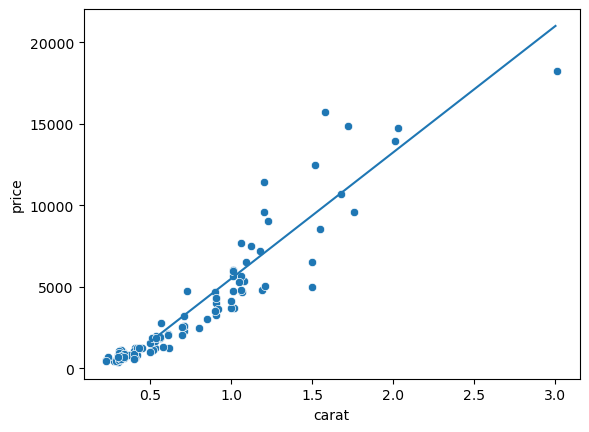

In [111]:
sns.scatterplot(data=df.sample(100), x="carat", y="price", ax=ax)
plt.show()